In [1]:
print("Hello")

Hello


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load from data folder
df = pd.read_csv('../data/nigeria.csv')

# Show column names
print("COLUMN NAMES:")
print(df.columns.tolist())

# Show first 3 rows
print("\nFIRST 3 ROWS:")
df.head(3)

COLUMN NAMES:
['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

FIRST 3 ROWS:


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43


Duplicates found: 0

=== SUMMARY STATISTICS ===
              T2M      T2M_MAX      T2M_MIN  PRECTOTCORR         RH2M  \
count  4108.00000  4108.000000  4108.000000  4108.000000  4108.000000   
mean     16.06850    23.199175    10.227544     3.633795    68.408588   
std       1.89805     2.751471     2.607256     6.289061    14.735838   
min      10.03000    15.650000     1.170000     0.000000    14.420000   
25%      14.82000    21.110000     8.417500     0.020000    59.030000   
50%      16.04000    22.740000    10.990000     0.820000    71.120000   
75%      17.36000    25.170000    12.220000     4.580000    80.802500   
max      21.53000    30.930000    15.680000    82.300000    91.930000   

              WS2M  
count  4108.000000  
mean      1.979998  
std       0.689093  
min       0.460000  
25%       1.407500  
50%       1.970000  
75%       2.480000  
max       4.130000  

=== MISSING VALUES (%) ===
Series([], dtype: float64)

=== OUTLIER COUNTS (|Z| > 3) ===
T2M: 3 outliers


C:\Users\beti\AppData\Local\Temp\ipykernel_6320\2230865331.py:62: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)



✅ Cleaned data saved to ../data/ethiopia_clean.csv


C:\Users\beti\AppData\Local\Temp\ipykernel_6320\2230865331.py:98: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\beti\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


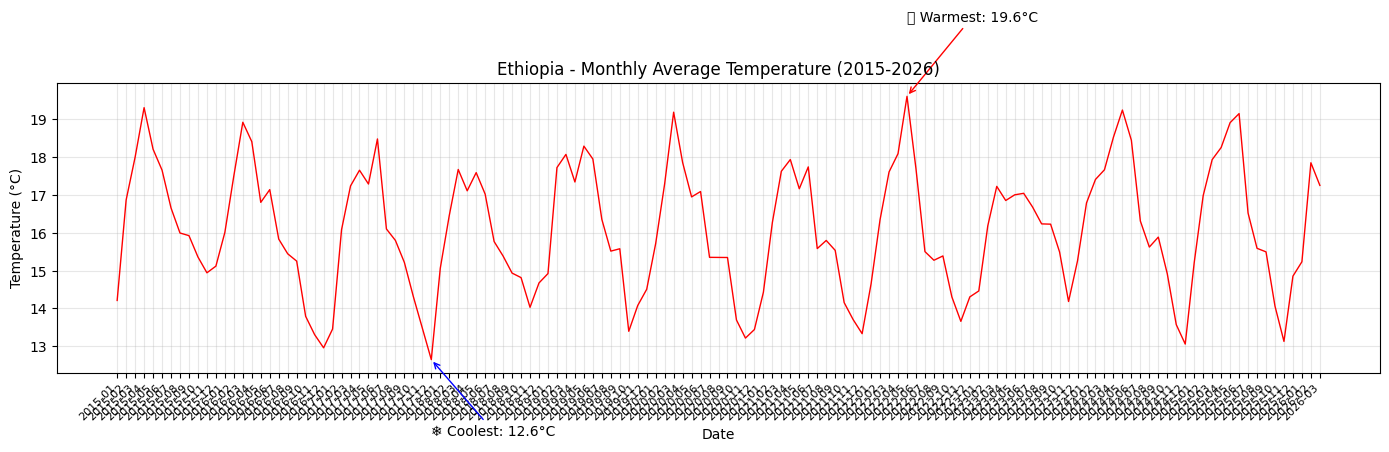

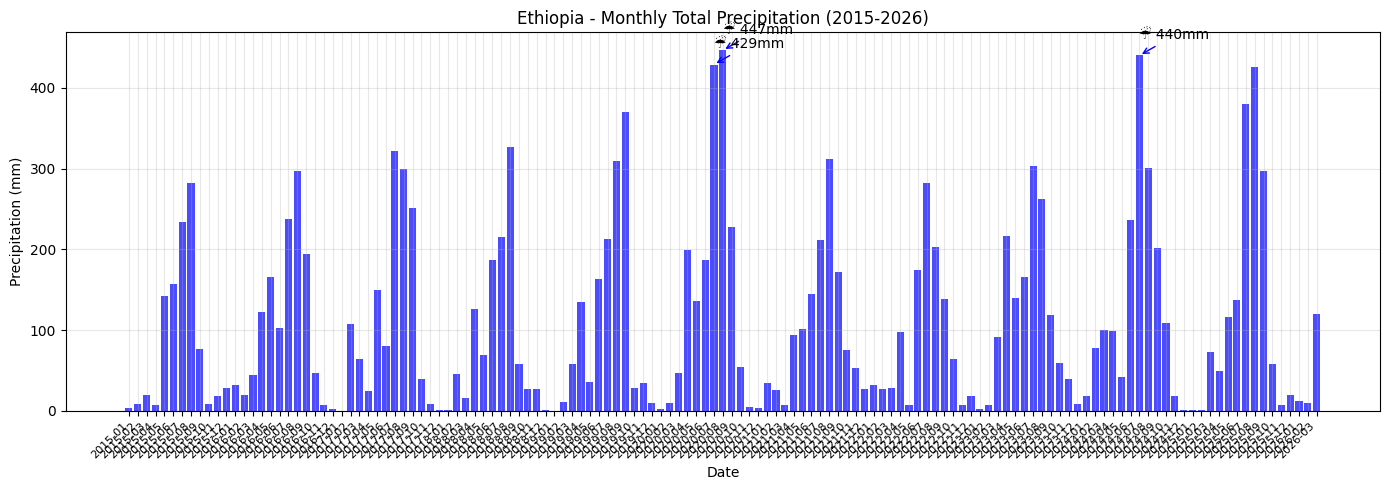

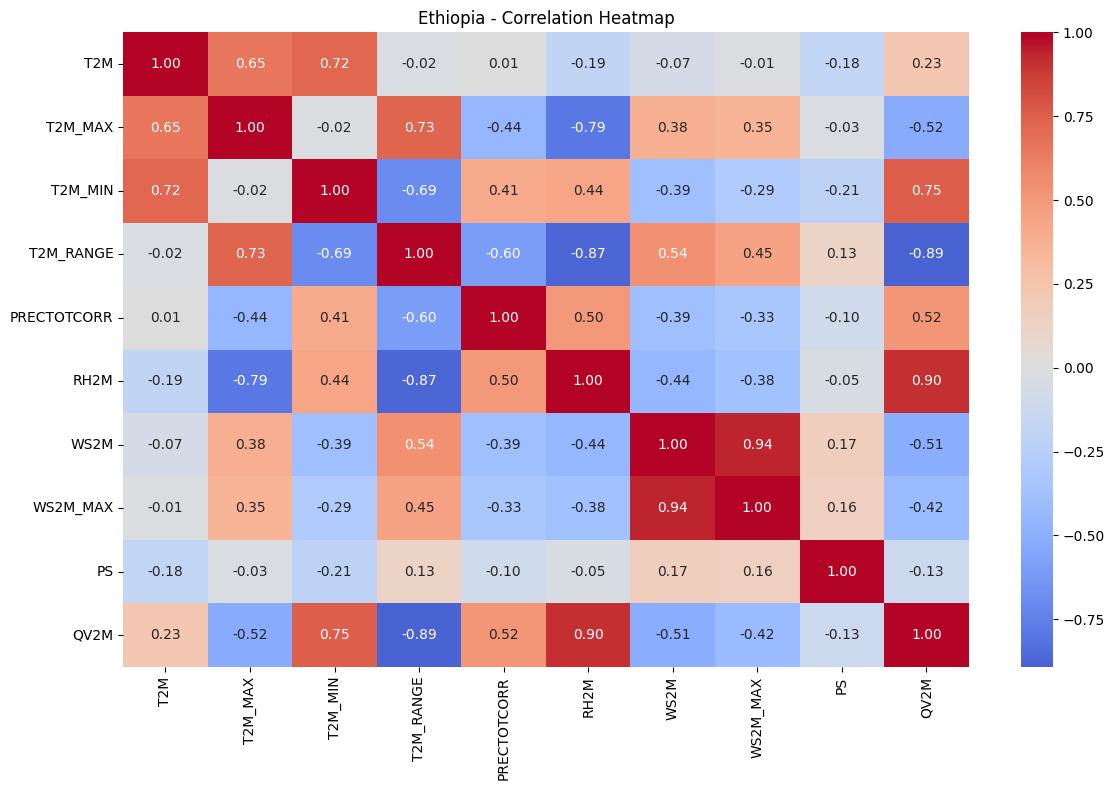

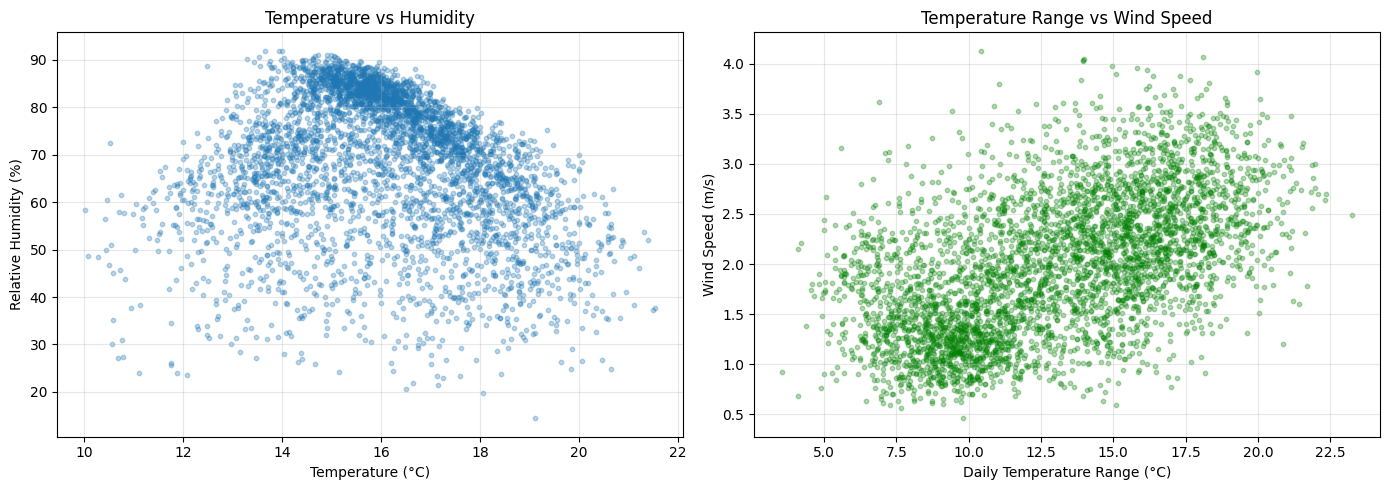

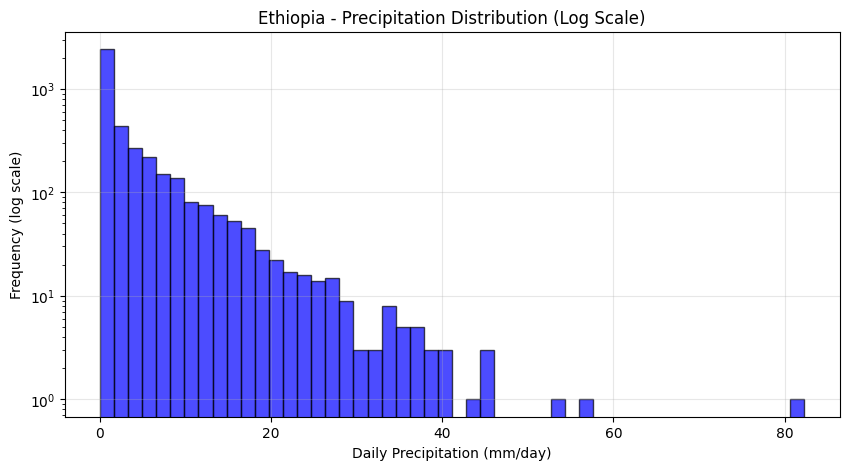

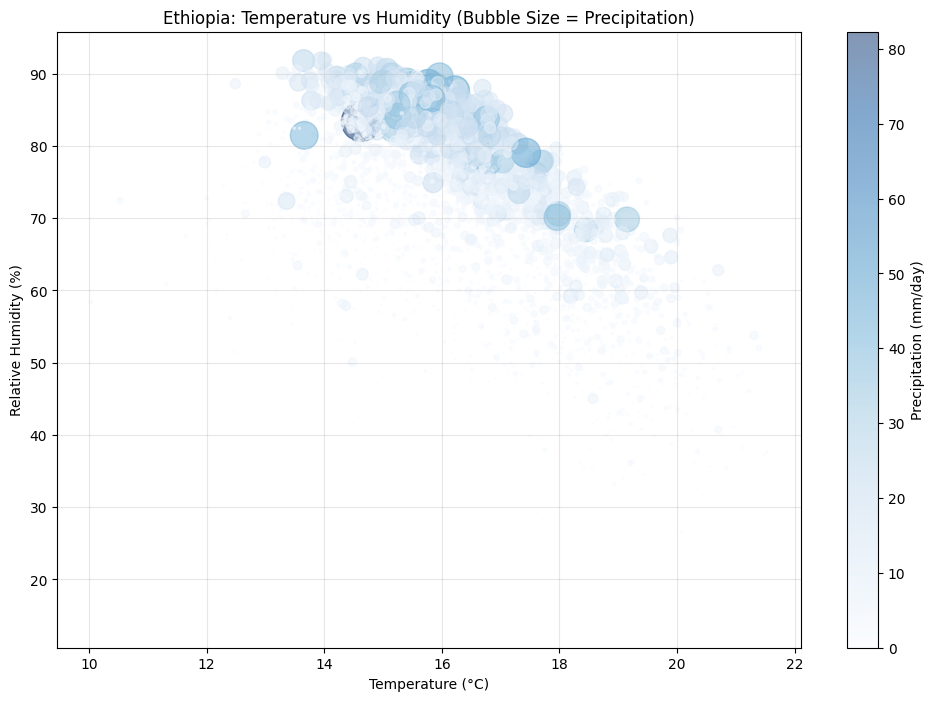


=== TOP 3 STRONGEST CORRELATIONS ===
1. WS2M vs WS2M_MAX: 0.941
2. RH2M vs QV2M: 0.905
3. T2M_MIN vs QV2M: 0.753


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================
# 1. LOAD DATA
# ============================================
df = pd.read_csv('../data/nigeria.csv')
df['Country'] = 'Nigeria'

# ============================================
# 2. HANDLE MISSING VALUES (-999 to NaN)
# ============================================
df.replace(-999, np.nan, inplace=True)

# ============================================
# 3. CREATE PROPER DATE
# ============================================
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')
df['Month'] = df['Date'].dt.month

# ============================================
# 4. CHECK DUPLICATES
# ============================================
print(f"Duplicates found: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# ============================================
# 5. SUMMARY STATISTICS
# ============================================
print("\n=== SUMMARY STATISTICS ===")
print(df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']].describe())

# ============================================
# 6. MISSING VALUES REPORT
# ============================================
print("\n=== MISSING VALUES (%) ===")
missing = df.isna().sum() / len(df) * 100
print(missing[missing > 0])

# ============================================
# 7. OUTLIER DETECTION (Z-score) - CORRECTED
# ============================================
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate z-scores for each column separately
print(f"\n=== OUTLIER COUNTS (|Z| > 3) ===")
for col in cols_to_check:
    col_clean = df[col].dropna()
    if len(col_clean) > 0:
        z_scores = np.abs(stats.zscore(col_clean))
        outlier_count = (z_scores > 3).sum()
        print(f"{col}: {outlier_count} outliers")
    else:
        print(f"{col}: No data")

# ============================================
# 8. HANDLE MISSING VALUES (forward fill)
# ============================================
df.fillna(method='ffill', inplace=True)
# Drop rows with >30% missing
df.dropna(thresh=0.7 * len(df.columns), inplace=True)

# ============================================
# 9. SAVE CLEANED DATA
# ============================================
df.to_csv('../data/nigeria_clean.csv', index=False)
print("\n✅ Cleaned data saved to ../data/nigeria_clean.csv")

# ============================================
# 10. TIME SERIES: Monthly average temperature
# ============================================
monthly_temp = df.groupby(df['Date'].dt.to_period('M'))['T2M'].mean()

plt.figure(figsize=(14,5))
plt.plot(monthly_temp.index.astype(str), monthly_temp.values, color='red', linewidth=1)
plt.title('Nigeria - Monthly Average Temperature (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(True, alpha=0.3)

# Annotate warmest and coolest
warmest_date = monthly_temp.idxmax()
warmest_val = monthly_temp.max()
coolest_date = monthly_temp.idxmin()
coolest_val = monthly_temp.min()

plt.annotate(f'🔥 Warmest: {warmest_val:.1f}°C', xy=(warmest_date.strftime('%Y-%m'), warmest_val), 
             xytext=(warmest_date.strftime('%Y-%m'), warmest_val+2), 
             arrowprops=dict(arrowstyle='->', color='red'))
plt.annotate(f'❄️ Coolest: {coolest_val:.1f}°C', xy=(coolest_date.strftime('%Y-%m'), coolest_val), 
             xytext=(coolest_date.strftime('%Y-%m'), coolest_val-2), 
             arrowprops=dict(arrowstyle='->', color='blue'))

plt.tight_layout()
plt.show()

# ============================================
# 11. BAR CHART: Monthly total precipitation
# ============================================
monthly_rain = df.groupby(df['Date'].dt.to_period('M'))['PRECTOTCORR'].sum()

plt.figure(figsize=(14,5))
plt.bar(monthly_rain.index.astype(str), monthly_rain.values, color='blue', alpha=0.7)
plt.title('Nigeria - Monthly Total Precipitation (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(True, alpha=0.3)

# Annotate peak rainy months (top 3)
top_3_months = monthly_rain.nlargest(3)
for date, value in top_3_months.items():
    plt.annotate(f'☔ {value:.0f}mm', xy=(date.strftime('%Y-%m'), value), 
                 xytext=(date.strftime('%Y-%m'), value+20), 
                 arrowprops=dict(arrowstyle='->', color='blue'))

plt.tight_layout()
plt.show()

# ============================================
# 12. CORRELATION HEATMAP
# ============================================
plt.figure(figsize=(12,8))
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Ethiopia - Correlation Heatmap')
plt.tight_layout()
plt.show()

# ============================================
# 13. SCATTER PLOTS
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Scatter 1: T2M vs RH2M
axes[0].scatter(df['T2M'], df['RH2M'], alpha=0.3, s=10)
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].set_title('Temperature vs Humidity')
axes[0].grid(True, alpha=0.3)

# Scatter 2: T2M_RANGE vs WS2M
axes[1].scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, s=10, color='green')
axes[1].set_xlabel('Daily Temperature Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].set_title('Temperature Range vs Wind Speed')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 14. PRECIPITATION DISTRIBUTION (log scale)
# ============================================
plt.figure(figsize=(10,5))
plt.hist(df['PRECTOTCORR'], bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.yscale('log')
plt.title('Nigeria - Precipitation Distribution (Log Scale)')
plt.xlabel('Daily Precipitation (mm/day)')
plt.ylabel('Frequency (log scale)')
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# 15. BUBBLE CHART: T2M vs RH2M (size = precipitation)
# ============================================
plt.figure(figsize=(12,8))
scatter = plt.scatter(df['T2M'], df['RH2M'], 
                      s=df['PRECTOTCORR'] * 10,  # size proportional to rain
                      alpha=0.5, c=df['PRECTOTCORR'], 
                      cmap='Blues')
plt.colorbar(scatter, label='Precipitation (mm/day)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Ethiopia: Temperature vs Humidity (Bubble Size = Precipitation)')
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# 16. TOP 3 CORRELATIONS
# ============================================
print("\n=== TOP 3 STRONGEST CORRELATIONS ===")
# Get upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Stack and sort
corr_pairs = upper.stack().sort_values(ascending=False)
for i in range(min(3, len(corr_pairs))):
    print(f"{i+1}. {corr_pairs.index[i][0]} vs {corr_pairs.index[i][1]}: {corr_pairs.values[i]:.3f}")



In [ ]:
df = df.replace(-999, np.nan)
df = df.drop_duplicates()

In [ ]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.plot(monthly_temp)
plt.title("Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

In [ ]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain)
plt.title("Monthly Rainfall")
plt.show()

In [ ]:
df.to_csv("data/ethiopia_clean.csv", index=False)